#### **Proyecto Innovador IA 1 - Problematic use of internet in children**

#### 1. Introducción y Configuración

Basados en los requerimientos del proyecto y nuestro análisis inicial, se han definido las siguientes estrategias clave para abordar el problema de predicción del uso problemático de internet en niños:

1.  **Ingeniería de Características:** Extracción de datos estadísticos de las series temporales (Parquet) y normalización por edad de los datos tabulares.
2.  **Imputación:** Uso de `KNNImputer` para manejar los bloques masivos de datos faltantes.
3.  **Validación Cruzada y Aumentación:** Implementación de `RepeatedStratifiedKFold` junto con aumentación de datos (ruido y sobremuestreo) para construir un modelo resistente al *overfitting*.
4.  **Optimización QWK:** Enfoque en regresión (prediciendo `PCIAT-PCIAT_Total`) y optimización matemática de umbrales para maximizar la métrica QWK.

In [1]:
# instalar lightgbm, tqdm
# !pip install lightgbm tqdm

In [ ]:
# --- 1. Importaciones de Librerías ---
# Esta celda contiene todas las librerías necesarias para el pipeline.

# Manejo de datos y cómputo
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y FE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer

# Modelado
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import cohen_kappa_score

# Optimización
from scipy.optimize import minimize

# Utilitarios
import os
from tqdm import tqdm
from pathlib import Path
import warnings
import random

# --- Configuración del Entorno ---
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None) # Mostrar todas las columnas

# Función de siembra para reproducibilidad
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

/home/wills/anaconda3/envs/master-IA/lib/python3.13/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


## 2. Carga de Datos y Estrategia de Objetivo

Cargamos los datos tabulares. Se definen variables importantes para el manejo de los datos:
* `DATA_DIR`: Carpeta en donde se encuentran los datos.
* `TARGET`: El *score* numérico (`PCIAT-PCIAT_Total`). **Este es el objetivo de nuestra regresión.**
* `SII_TARGET`: La clase ordinal (`sii`). **Este SÓLO se usará para la estratificación de CV y la métrica QWK final.**
* `ID_COL`: La columna de identificación.

---
#### **Importar datasets**

In [3]:
# --- 2. Carga de Datos Tabulares ---
# Definimos la ruta y cargamos los archivos CSV principales.

# Define la ruta donde se encuentran los datos
DATA_DIR = Path('./data')

# Variables estratégicas
TARGET = 'PCIAT-PCIAT_Total'
SII_TARGET = 'sii'
ID_COL = 'id'

# Se cargan los datos de los archivos CSV
train_csv = pd.read_csv(DATA_DIR / 'train.csv')
test_csv = pd.read_csv(DATA_DIR / 'test.csv')

print(f"train Shape: {train_csv.shape}")
print(f"test Shape: {test_csv.shape}")

train Shape: (3960, 82)
test Shape: (20, 59)


## 3. EDA Inicial y Prevención de Fuga de Datos (Data Leakage)

Antes de realizar cualquier análisis, debemos identificar y aislar cualquier columna que pueda causar **fuga de datos (data leakage)**. Del análisis realizado en la primera entrega, la información del reto en Kaggle y del conocimiento del negicio sabemos que el *target* (`sii`) se deriva del *score* total del cuestionario (`PCIAT-PCIAT_Total`).

**Nuestra hipótesis es:** El `train.csv` contiene las respuestas a las preguntas individuales (ej. `PCIAT-PCIAT_01`, `PCIAT-PCIAT_02`, etc.) que se usan para calcular el *score* total. Estas columnas **no están disponibles** en el *test set*, por lo tanto, usarlas en el entrenamiento es una fuga de datos.

Vamos a verificar esta hipótesis comparando las columnas de `train` y `test`.

In [4]:
# --- 3.1 Identificación de Columnas con Fuga de Datos ---

# Comparar los conjuntos de columnas para encontrar diferencias
train_cols = set(train_csv.columns)
test_cols = set(test_csv.columns)

cols_solo_en_train = train_cols.difference(test_cols)

print(f"Total de columnas en 'train': {len(train_cols)}")
print(f"Total de columnas en 'test': {len(test_cols)}")
print("\nColumnas que están en 'train' pero NO en 'test':")
print(cols_solo_en_train)

Total de columnas en 'train': 82
Total de columnas en 'test': 59

Columnas que están en 'train' pero NO en 'test':
{'PCIAT-PCIAT_09', 'sii', 'PCIAT-PCIAT_08', 'PCIAT-PCIAT_15', 'PCIAT-PCIAT_19', 'PCIAT-PCIAT_11', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_06', 'PCIAT-PCIAT_12', 'PCIAT-PCIAT_03', 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_02', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_18', 'PCIAT-PCIAT_20', 'PCIAT-Season', 'PCIAT-PCIAT_07', 'PCIAT-PCIAT_14', 'PCIAT-PCIAT_10', 'PCIAT-PCIAT_Total'}


Se comprueba la hipótesis, las columnas `PCIAT` se deben eliminar del conjunto de entrenamiento para evitar fuga de datos.

In [5]:
# --- 3.2 Creación de DataFrames Limpios ---

# Definimos nuestras features como las columnas de 'test', sin id
FEATURES = [col for col in test_csv.columns if col != ID_COL]

# Filtramos 'train'
train = train_csv[[ID_COL] + FEATURES + [TARGET, SII_TARGET]]

# Se renombra test por consistencia
test = test_csv

print("\n--- DataFrames después de la limpieza de 'leakers' ---")
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Número de features: {len(FEATURES)}")


--- DataFrames después de la limpieza de 'leakers' ---
Train shape: (3960, 61)
Test shape: (20, 59)
Número de features: 58


## 4. EDA: evaluaciones clínicas o auto-reportes de comportamiento

El objetivo es predecir `PCIAT-PCIAT_Total` a partir de indicadores de actividad y condición física, evitando variables provenientes de evaluaciones clínicas o auto-reportes de comportamiento.

Se identifican las siguientes columnas relacionadas con evaluaciones clínicas o auto-reportes de comportamiento:

**Evaluación Clínica (CGAS):**
- `CGAS-Season`
- `CGAS-CGAS_Score`
  
**Cuestionario Clínico (SDS):**
- `SDS-Season`
- `SDS-SDS_Total_Raw`
- `SDS-SDS_Total_T`

**Auto-Reporte de Conducta (Internet):**
- `PreInt_EduHx-Season`
- `PreInt_EduHx-computerinternet_hoursday`

In [6]:
# --- 3.3 Eliminar variables de evaluaciones clínicas o auto-reportes de comportamiento ---

clinical_eval_cols = [
    'CGAS-Season', 
    'CGAS-CGAS_Score', 
    'SDS-Season', 
    'SDS-SDS_Total_Raw', 
    'SDS-SDS_Total_T', 
    'PreInt_EduHx-Season', 
    'PreInt_EduHx-computerinternet_hoursday'
]

# Eliminar de FEATURES las columnas de evaluaciones clínicas
FEATURES = [col for col in FEATURES if col not in clinical_eval_cols]

print(f"Se excluyeron {len(clinical_eval_cols)} columnas de evaluaciones clínicas/auto-reportes")
print(f"Número de features restantes: {len(FEATURES)}")

Se excluyeron 7 columnas de evaluaciones clínicas/auto-reportes
Número de features restantes: 51


## 4. EDA: Análisis de Valores Nulos

Realizaremos un análisis cuantitativo. Agruparemos las *features* según su porcentaje de datos faltantes. Esto nos dirá qué columnas son "usables", cuáles necesitan "imputación" y cuáles son "casi inútiles".

In [7]:
# --- 4.1 EDA: Resumen Cuantitativo de Nulos ---

# 1. Calcular el porcentaje de nulos para nuestras 58 FEATURES
null_pct = (train[FEATURES].isnull().sum() / len(train)) * 100
null_pct = null_pct.sort_values(ascending=False)

# 2. Mostrar un resumen en grupos críticos
print("--- Resumen de Valores Nulos (Porcentaje Faltante) ---")

print("\n[--- GRUPO 1: 'El Desastre' (> 70% de Nulos) ---]")
print(null_pct[null_pct > 70])
print(f"Total de 'features' en este grupo: {len(null_pct[null_pct > 70])}")

print("\n[--- GRUPO 2: 'Bloques Faltantes' (30% - 70% Nulos) ---]")
print(null_pct[(null_pct > 30) & (null_pct <= 70)])
print(f"Total de 'features' en este grupo: {len(null_pct[(null_pct > 30) & (null_pct <= 70)])}")

print("\n[--- GRUPO 3: 'Datos Usables' (< 30% Nulos) ---]")
print(null_pct[(null_pct > 0) & (null_pct <= 30)])
print(f"Total de 'features' en este grupo: {len(null_pct[(null_pct > 0) & (null_pct <= 30)])}")

print("\n[--- GRUPO 4: 'Features de Anclaje' (0% Nulos) ---]")
print(null_pct[null_pct == 0])
print(f"Total de 'features' en este grupo: {len(null_pct[null_pct == 0])}")

print("\n--- Conteo Total ---")
print(f"Total de features analizadas: {len(FEATURES)}")

--- Resumen de Valores Nulos (Porcentaje Faltante) ---

[--- GRUPO 1: 'El Desastre' (> 70% de Nulos) ---]
PAQ_A-PAQ_A_Total               88.005051
PAQ_A-Season                    88.005051
Fitness_Endurance-Time_Mins     81.313131
Fitness_Endurance-Time_Sec      81.313131
Fitness_Endurance-Max_Stage     81.237374
Physical-Waist_Circumference    77.323232
FGC-FGC_GSND_Zone               73.181818
FGC-FGC_GSD_Zone                73.156566
FGC-FGC_GSND                    72.878788
FGC-FGC_GSD                     72.878788
dtype: float64
Total de 'features' en este grupo: 10

[--- GRUPO 2: 'Bloques Faltantes' (30% - 70% Nulos) ---]
Fitness_Endurance-Season      66.969697
PAQ_C-Season                  56.540404
PAQ_C-PAQ_C_Total             56.540404
BIA-BIA_BMR                   49.722222
BIA-BIA_Activity_Level_num    49.722222
BIA-BIA_DEE                   49.722222
BIA-BIA_ECW                   49.722222
BIA-BIA_FFM                   49.722222
BIA-BIA_FFMI                  49.722222
BIA

## 4. EDA: Conclusiones del Análisis de Nulos:

1.  **Features de Anclaje (Grupo 4):** Tenemos 3 *features* 100% completas (`Basic_Demos-Age`, `Basic_Demos-Sex`, `Basic_Demos-Enroll_Season`). Estas serán las "anclas" fiables de nuestro modelo.

2.  **Bloques Faltantes (Grupo 2):** Vemos que las 17 *features* de `BIA-BIA_...` tienen el mismo porcentaje de nulos (`49.72%`). Algo parecido ocurre con las *features* de `FGC-FGC_...` (`~41-42%`). Los datos faltan en "bloques". Si un participante no realizó la prueba BIA, faltan las 17 mediciones.

3.  **El Desastre (Grupo 1):** Las 10 *features* de este grupo (como `PAQ_A`, el cuestionario de adolescentes, y `Fitness_Endurance`) están casi vacías. Es probable que no aporten mucho valor.

**Estrategia:**
* Una imputación por media/mediana simple sería un error, ya que ignoraría la naturaleza de "bloque" de los datos.
* Planteamos usar **`KNNImputer`**. Este método usará las "Features de Anclaje" (como Edad y Sexo) para encontrar a los participantes más similares (los "k-vecinos") y hacer una imputación inteligente para los "Bloques Faltantes" (BIA y FGC).
* Para el "Grupo 1", el imputador rellenará los valores y después podremos evaluar su impacto en el modelo seleccionado.

A continuación, analizamos nuestras variables objetivo.

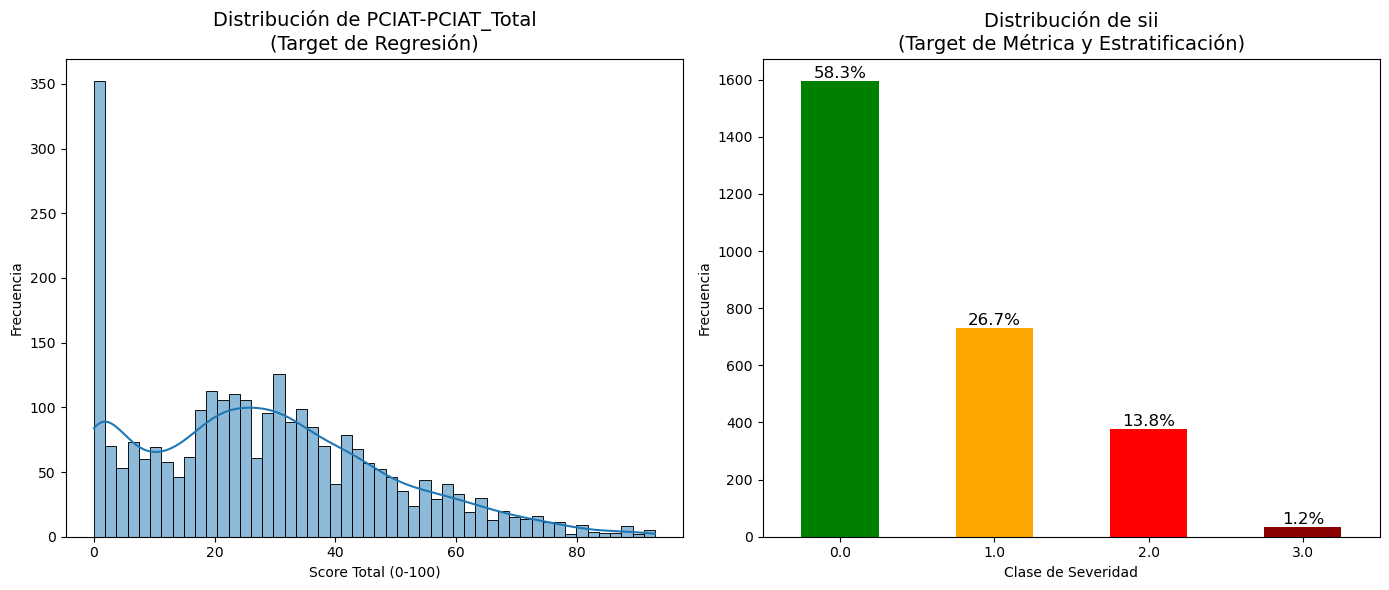


--- Distribución de Clases SII (Target de Métrica) ---
sii
0.0    58.260234
1.0    26.681287
2.0    13.815789
3.0     1.242690
Name: proportion, dtype: float64


In [8]:
# --- 4.2 EDA: Análisis de las Variables Objetivo ---

# Filtramos las filas donde los targets son nulos.
train_targets = train.dropna(subset=[TARGET, SII_TARGET, ID_COL])

# Gráfico 1: Target de Regresión (Score)
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(train_targets[TARGET], kde=True, bins=50)
plt.title(f"Distribución de {TARGET}\n(Target de Regresión)", fontsize=14)
plt.xlabel("Score Total (0-100)")
plt.ylabel("Frecuencia")

# Gráfico 2: Target de Métrica (Clase)
plt.subplot(1, 2, 2)
ax = train_targets[SII_TARGET].value_counts().sort_index().plot(
    kind='bar', 
    color=['green', 'orange', 'red', 'darkred']
)
plt.title(f"Distribución de {SII_TARGET}\n(Target de Métrica y Estratificación)", fontsize=14)
plt.xlabel("Clase de Severidad")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)

# Añadir porcentajes al gráfico de barras
total = len(train_targets)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, color='black')

plt.tight_layout()
plt.show()

print("\n--- Distribución de Clases SII (Target de Métrica) ---")
print(train_targets[SII_TARGET].value_counts(normalize=True).sort_index() * 100)

## 4. EDA: Conclusiones del Análisis de Objetivo

1.  **Target de Regresión (`PCIAT-PCIAT_Total`):** El histograma muestra que los datos no siguen una distribución normal. Están **fuertemente sesgados a la derecha**, con una gran acumulación de *scores* bajos y en cero. Esto sugiere que un modelo de regresión simple (como Regresión Lineal) fallaría. Un modelo basado en árboles (`LightGBM`) que pueda manejar distribuciones no lineales será una mejor primera opción, además nos ayudaría con las características categóricas.

2.  **Target de Métrica (`sii`):** La distribución de clases es **extremadamente desbalanceada**. La **Clase 3 ("Severo") representa solo el 1.2%**.

**Estrategia:**
* No podemos usar una validación cruzada (`KFold`) simple, ya que algunos *folds* podrían no tener *ningún* ejemplo de la Clase 3. Por lo tanto, usaremos **`StratifiedKFold`**.
* Dado el desbalance, es muy probable que nuestro modelo ignore a la Clase 3. Para combatir esto, exploraremos técnicas de **aumentación de datos**, específicamente **sobremuestreo (oversampling)** de las clases raras (`2` y `3`).

## 4. EDA: Exploración de archivos parquet

In [9]:
# --- 5.0 Exploración de Archivos Parquet ---
# Visualización de las primeras filas de 10 archivos para verificar estructura y columnas

print("--- Explorando estructura de archivos Parquet ---\n")

# Obtener lista de archivos
train_series_dir = DATA_DIR / 'series_train.parquet'
id_paths = list(train_series_dir.glob('id=*'))[:10]  # Primeros 10 archivos

for i, id_path in enumerate(id_paths, 1):
    id_str = id_path.name.split('=')[1]
    print(f"\n{'='*70}")
    print(f"Archivo {i}/10 - ID: {id_str}")
    print(f"{'='*70}")
    
    try:
        # Cargar el archivo parquet completo
        df = pd.read_parquet(id_path / 'part-0.parquet')
        
        print(f"\nShape: {df.shape}")
        print("\nColumnas disponibles:")
        print(df.columns.tolist())
        print("\nTipos de datos:")
        print(df.dtypes)
        print("\nPrimeras 5 filas:")
        display(df.head())
        
        # Estadísticas básicas de non-wear_flag si existe
        if 'non-wear_flag' in df.columns:
            non_wear_pct = df['non-wear_flag'].mean() * 100
            print(f"\nPorcentaje de non-wear: {non_wear_pct:.2f}%")
        
    except Exception as e:
        print(f"Error al leer archivo: {e}")

print(f"\n{'='*70}")
print("Exploración completada")
print(f"{'='*70}")

--- Explorando estructura de archivos Parquet ---


Archivo 1/10 - ID: a49eda7f

Shape: (370692, 13)

Columnas disponibles:
['step', 'X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'battery_voltage', 'time_of_day', 'weekday', 'quarter', 'relative_date_PCIAT']

Tipos de datos:
step                    uint32
X                      float32
Y                      float32
Z                      float32
enmo                   float32
anglez                 float32
non-wear_flag          float32
light                  float32
battery_voltage        float32
time_of_day              int64
weekday                   int8
quarter                   int8
relative_date_PCIAT    float32
dtype: object

Primeras 5 filas:


,step,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,time_of_day,weekday,quarter,relative_date_PCIAT
0,0,-0.366671,-0.090229,0.709178,0.050130,64.249557,0.0,3.50,4184.000000,60060000000000,2,4,5.0
1,1,-0.278385,-0.345847,0.694275,0.029810,45.537891,0.0,3.25,4183.583496,60065000000000,2,4,5.0
2,2,0.768756,0.456682,0.018468,0.029778,1.520453,0.0,3.00,4183.166504,60070000000000,2,4,5.0
3,3,0.379417,0.565705,0.560129,0.028612,37.443703,0.0,2.75,4182.750000,60075000000000,2,4,5.0
4,4,-0.159012,-0.164889,0.904651,0.032048,68.001968,0.0,2.50,4182.333496,60080000000000,2,4,5.0



Porcentaje de non-wear: 0.00%

Archivo 2/10 - ID: f47abc42

Shape: (254519, 13)

Columnas disponibles:
['step', 'X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'battery_voltage', 'time_of_day', 'weekday', 'quarter', 'relative_date_PCIAT']

Tipos de datos:
step                    uint32
X                      float32
Y                      float32
Z                      float32
enmo                   float32
anglez                 float32
non-wear_flag          float32
light                  float32
battery_voltage        float32
time_of_day              int64
weekday                   int8
quarter                   int8
relative_date_PCIAT    float32
dtype: object

Primeras 5 filas:


,step,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,time_of_day,weekday,quarter,relative_date_PCIAT
0,0,-0.203112,0.943401,-0.151125,0.023504,-9.291838,0.0,14.400000,4185.000000,38760000000000,3,2,12.0
1,1,-0.213153,0.535127,-0.126081,0.034423,-9.523173,0.0,11.800000,4184.333496,38765000000000,3,2,12.0
2,2,-0.750052,0.199334,0.444703,0.044208,27.325245,0.0,3.800000,4183.666504,38770000000000,3,2,12.0
3,3,-0.722108,-0.000739,0.512416,0.033308,33.135345,0.0,3.000000,4183.000000,38775000000000,3,2,12.0
4,4,-0.767021,-0.205109,0.500571,0.021700,31.503866,0.0,1.666667,4182.333496,38780000000000,3,2,12.0



Porcentaje de non-wear: 0.00%

Archivo 3/10 - ID: 8a4e5d1a

Shape: (411972, 13)

Columnas disponibles:
['step', 'X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'battery_voltage', 'time_of_day', 'weekday', 'quarter', 'relative_date_PCIAT']

Tipos de datos:
step                    uint32
X                      float32
Y                      float32
Z                      float32
enmo                   float32
anglez                 float32
non-wear_flag          float32
light                  float32
battery_voltage        float32
time_of_day              int64
weekday                   int8
quarter                   int8
relative_date_PCIAT    float32
dtype: object

Primeras 5 filas:


...


Porcentaje de non-wear: 33.96%

Archivo 9/10 - ID: 7860b64c

Shape: (447144, 13)

Columnas disponibles:
['step', 'X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'battery_voltage', 'time_of_day', 'weekday', 'quarter', 'relative_date_PCIAT']

Tipos de datos:
step                    uint32
X                      float32
Y                      float32
Z                      float32
enmo                   float32
anglez                 float32
non-wear_flag          float32
light                  float32
battery_voltage        float32
time_of_day              int64
weekday                   int8
quarter                   int8
relative_date_PCIAT    float32
dtype: object

Primeras 5 filas:


,step,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,time_of_day,weekday,quarter,relative_date_PCIAT
0,0,-0.093965,-0.040300,-0.986496,2.436797e-05,-84.071465,0.0,2.0,4170.00,57540000000000,3,4,29.0
1,1,-0.094030,-0.040208,-0.986026,0.000000e+00,-84.100677,0.0,2.0,4170.25,57545000000000,3,4,29.0
2,2,-0.093991,-0.040024,-0.985439,0.000000e+00,-84.096848,0.0,1.5,4170.50,57550000000000,3,4,29.0
3,3,-0.094056,-0.040273,-0.985557,0.000000e+00,-84.115685,0.0,3.0,4170.75,57555000000000,3,4,29.0
4,4,-0.094212,-0.039565,-0.985257,5.157789e-07,-84.068741,0.0,1.5,4171.00,57560000000000,3,4,29.0



Porcentaje de non-wear: 16.97%

Archivo 10/10 - ID: 31648caa

Shape: (406740, 13)

Columnas disponibles:
['step', 'X', 'Y', 'Z', 'enmo', 'anglez', 'non-wear_flag', 'light', 'battery_voltage', 'time_of_day', 'weekday', 'quarter', 'relative_date_PCIAT']

Tipos de datos:
step                    uint32
X                      float32
Y                      float32
Z                      float32
enmo                   float32
anglez                 float32
non-wear_flag          float32
light                  float32
battery_voltage        float32
time_of_day              int64
weekday                   int8
quarter                   int8
relative_date_PCIAT    float32
dtype: object

Primeras 5 filas:


,step,X,Y,Z,enmo,anglez,non-wear_flag,light,battery_voltage,time_of_day,weekday,quarter,relative_date_PCIAT
0,0,0.557052,0.332804,0.097429,0.049073,10.947793,0.0,4.200000,4182.000000,58380000000000,2,4,242.0
1,1,-0.058280,0.826378,-0.414207,0.051213,-26.164774,0.0,0.333333,4181.916504,58385000000000,2,4,242.0
2,2,0.727454,0.444462,0.020481,0.026610,0.864961,0.0,0.666667,4181.833496,58390000000000,2,4,242.0
3,3,0.618371,0.687394,-0.193618,0.023863,-11.019281,0.0,35.799999,4181.750000,58395000000000,2,4,242.0
4,4,0.392547,0.340052,-0.767467,0.063765,-53.581783,0.0,0.000000,4181.666504,58400000000000,2,4,242.0



Porcentaje de non-wear: 9.12%

Exploración completada


## 5. Ingeniería de Características (Parquet - Segmentación Circadiana y Estadísticas)

Aquí se procesarán los **996 archivos Parquet** de series temporales de actigrafía.

Estos archivos contienen millones de mediciones de alta frecuencia (acelerómetro, luz). El objetivo es **"aplanar"** estas series en una sola fila de *features* estadísticas robustas por sujeto.

**Estrategia de Extracción y Limpieza:**

1.  **Limpieza (`non-wear`):**
    * Los datos incluyen una columna `non-wear_flag` (1 = no usando, 0 = usando).
    * Calcular estadísticas de movimiento sobre datos donde el reloj estaba en una mesa (`flag=1`) contaminaría las *features*.
    * **Acción:** Filtramos estrictamente por `non-wear_flag == 0` para las estadísticas de movimiento, pero calculamos `pct_non_wear` globalmente como una *feature* de comportamiento (cumplimiento).

2.  **Segmentación Temporal (Ritmo Circadiano):**
    * El comportamiento varía drásticamente entre el día y la noche. Un niño quieto a las 3 PM es diferente a uno quieto a las 3 AM.
    * **Global:** Todo el tiempo de uso.
    * **Día:** 07:00 a 20:00 (Actividad esperada).
    * **Noche:** 22:00 a 05:00 (Sueño esperado).

3.  **Agregación Estadística (El "ADN" del Movimiento):**
    Para cada señal (`X`, `Y`, `Z`, `enmo`, `anglez`, `light`) y segmento, calculamos:

    * **Tendencia Central (`mean`, `std`, `min`, `max`):** Las constantes vitales básicas. Nivel promedio, variabilidad y extremos.
    * **Forma (`skew`, `kurtosis`):** Describen la *naturaleza* de la actividad.
        * *Skew:* ¿Picos explosivos o actividad constante?
        * *Kurtosis:* ¿Datos muy concentrados en cero (quietud) con ráfagas extremas?
    * **Robustez (`q25`, `q75`):** El rango intercuartílico nos da el comportamiento "normal" ignorando *outliers*.
    * **Dinámica (`diff_mean`, `diff_std`):** Mide la **"tasa de cambio"**.
        * *Ejemplo:* Un `anglez_diff_std` bajo indica que el brazo mantiene la misma postura por largos periodos (ej. durmiendo o usando un computador), mientras que uno alto indica cambio constante.

In [10]:
# --- 5.1 Ingeniería de características de datos Parquet ---

# 1. Definir columnas a cargar y analizar
LOAD_COLS = ["step", "X", "Y", "Z", "enmo", "anglez", "light", "non-wear_flag", "time_of_day"]
SIGNAL_COLS = ["X", "Y", "Z", "enmo", "anglez", "light"]

# 2. Función para procesar un solo archivo parquet
def process_file_pandas(id_path):
    id_str = id_path.name.split('=')[1]
    
    try:
        # --- A. Carga ---
        # Cargamos el DF completo usando el nombre correcto de columna
        df = pd.read_parquet(id_path / 'part-0.parquet', columns=LOAD_COLS)
                    
        # Calcular la feature de comportamiento para detectar no uso
        pct_non_wear = df["non-wear_flag"].mean()
        
        # Convertir nanosegundos a horas
        df['hour'] = df['time_of_day'] // (3600 * 1_000_000_000)
        
        # --- B. Definición de Máscaras ---
        # 1. Máscara Base: El reloj se está usando (valor 0)
        mask_wear = (df["non-wear_flag"] == 0)
        
        # 2. Máscaras Temporales
        # Día: 7 AM a 8 PM
        mask_day = (df['hour'] >= 7) & (df['hour'] <= 20)
        # Noche: 10 pm a 5 am
        mask_night = (df['hour'] >= 22) | (df['hour'] <= 5)
        
        # Diccionario de segmentos
        segments = {
            '': mask_wear, # Global
            '_day': mask_wear & mask_day, # Día
            '_night': mask_wear & mask_night # Noche
        }
        
        # --- C. Extracción de Estadísticas ---
        feats_dict = {'id': id_str, 'pct_non_wear': pct_non_wear}
        
        for seg_name, mask in segments.items():
            # Filtrar los datos
            df_seg = df[mask]
            
            if df_seg.empty:
                continue
            
            # Calcular stats
            for col in SIGNAL_COLS:
                col_data = df_seg[col]
                
                feats_dict[f"{col}{seg_name}_mean"] = col_data.mean()
                feats_dict[f"{col}{seg_name}_std"] = col_data.std()
                feats_dict[f"{col}{seg_name}_min"] = col_data.min()
                feats_dict[f"{col}{seg_name}_max"] = col_data.max()
                feats_dict[f"{col}{seg_name}_skew"] = col_data.skew()
                feats_dict[f"{col}{seg_name}_kurt"] = col_data.kurt()
                feats_dict[f"{col}{seg_name}_q25"] = col_data.quantile(0.25)
                feats_dict[f"{col}{seg_name}_q75"] = col_data.quantile(0.75)
                feats_dict[f"{col}{seg_name}_diff_mean"] = col_data.diff().mean()
                feats_dict[f"{col}{seg_name}_diff_std"] = col_data.diff().std()

        return feats_dict
    
    except Exception as e:
        print(f"Error procesando {id_str}: {e}")
        return None

# 3. Función principal
def build_features_df(series_dir, desc="Procesando Parquet"):
    print(f"Iniciando procesamiento: {series_dir}")
    id_paths = list(series_dir.glob('id=*'))
    all_features = []
    
    for id_path in tqdm(id_paths, desc=desc):
        features = process_file_pandas(id_path)
        if features:
            all_features.append(features)
    
    df_parquet_features = pd.DataFrame(all_features)
    return df_parquet_features

# --- 5.2 Ejecución ---
print("--- Iniciando Procesamiento de Features parquet ---")

PARQUET_OUT_TRAIN = 'train_parquet_features.csv'
PARQUET_OUT_TEST = 'test_parquet_features.csv'

try:
    train_parquet_features = pd.read_csv(DATA_DIR / PARQUET_OUT_TRAIN)
    test_parquet_features = pd.read_csv(DATA_DIR / PARQUET_OUT_TEST)
    print("Features Parquet cargadas desde archivos CSV.")
    
except FileNotFoundError:
    print("Archivos no encontrados. Iniciando procesamiento...")
    
    train_series_dir = DATA_DIR / 'series_train.parquet'
    train_parquet_features = build_features_df(train_series_dir, desc="Train Parquet")

    test_series_dir = DATA_DIR / 'series_test.parquet'
    test_parquet_features = build_features_df(test_series_dir, desc="Test Parquet")

    # Guardar
    train_parquet_features.to_csv(DATA_DIR / PARQUET_OUT_TRAIN, index=False)
    test_parquet_features.to_csv(DATA_DIR / PARQUET_OUT_TEST, index=False)
    print("\n--- ¡Procesamiento Completado! ---")

print(f"Train features shape: {train_parquet_features.shape}")
print(f"Test features shape: {test_parquet_features.shape}")

--- Iniciando Procesamiento de Features parquet ---
Features Parquet cargadas desde archivos CSV.
Train features shape: (996, 182)
Test features shape: (2, 182)


## 6. Fusión de Datos y Creación del Dataset Completo

Con el EDA tabular y el procesamiento de Parquet completados, ahora tenemos dos conjuntos de *features*:

1.  `train` (3960, 61): Los datos tabulares originales (demografía, físicos, etc.), limpios de *leakers*.
2.  `train_parquet_features` (996, 182): Los nuevos agregados estadísticos de la actigrafía (X, Y, Z, enmo, etc.), ya limpios de datos `non-wear`.

Vamos a **unir (merge)** estas dos fuentes usando la `id` como clave.

Podemos ver que `train` tabular tiene 3960 filas, pero el de Parquet solo 996. Esto es un hallazgo importante: **solo 996 de los 3960 participantes tienen datos de actigrafía**.

Usaremos un `left join` (unión izquierda) para crear un *dataset* completo. Los 3960 participantes se mantendrán, y aquellos sin datos de actigrafía simplemente tendrán `NaN` en esas 181 nuevas columnas. Esto es esperado y será manejado por el imputador en el siguiente paso.

In [11]:
# --- 6.1 Fusión de Fuentes de Datos ---

print(f"Shape de 'train' tabular ANTES de la unión: {train.shape}")
print(f"Shape de 'train_parquet_features' ANTES de la unión: {train_parquet_features.shape}")

train_full = train.merge(train_parquet_features, on=ID_COL, how='left')
test_full = test.merge(test_parquet_features, on=ID_COL, how='left')

# --- 6.2 Actualizar nuestra lista de FEATURES ---

# Capturamos las nuevas columnas de parquet
parquet_feature_cols = [col for col in train_parquet_features.columns if col != ID_COL]

original_feature_count = len(FEATURES)

# Nuestra lista final de FEATURES es la lista original 58 + las nuevas 181
FEATURES = FEATURES + parquet_feature_cols

print(f"\nNúmero de features tabulares originales: {original_feature_count}")
print(f"Número de features parquet añadidas: {len(parquet_feature_cols)}")
print(f"Número TOTAL de features para el modelo: {len(FEATURES)}")

print(f"\nShape de 'train' completo despues de la unión: {train_full.shape}")
print(f"Shape de 'test' completo despues de la unión: {test_full.shape}")

# Inspeccionar el resultado
print("\nHead del DataFrame 'train' completo (mostrando nulos):")
display(train_full.head())

Shape de 'train' tabular ANTES de la unión: (3960, 61)
Shape de 'train_parquet_features' ANTES de la unión: (996, 182)

Número de features tabulares originales: 51
Número de features parquet añadidas: 181
Número TOTAL de features para el modelo: 232

Shape de 'train' completo despues de la unión: (3960, 242)
Shape de 'test' completo despues de la unión: (20, 240)

Head del DataFrame 'train' completo (mostrando nulos):


,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Season,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,PCIAT-PCIAT_Total,sii,pct_non_wear,X_mean,X_std,X_min,X_max,X_skew,X_kurt,X_q25,X_q75,X_diff_mean,X_diff_std,Y_mean,Y_std,Y_min,Y_max,Y_skew,Y_kurt,Y_q25,Y_q75,Y_diff_mean,Y_diff_std,Z_mean,Z_std,Z_min,Z_max,Z_skew,Z_kurt,Z_q25,Z_q75,Z_diff_mean,Z_diff_std,enmo_mean,enmo_std,enmo_min,enmo_max,enmo_skew,enmo_kurt,enmo_q25,enmo_q75,enmo_diff_mean,enmo_diff_std,anglez_mean,anglez_std,anglez_min,anglez_max,anglez_skew,anglez_kurt,anglez_q25,anglez_q75,anglez_diff_mean,anglez_diff_std,light_mean,light_std,light_min,light_max,light_skew,light_kurt,light_q25,light_q75,light_diff_mean,light_diff_std,X_day_mean,X_day_std,X_day_min,X_day_max,X_day_skew,X_day_kurt,X_day_q25,X_day_q75,X_day_diff_mean,X_day_diff_std,Y_day_mean,Y_day_std,Y_day_min,Y_day_max,Y_day_skew,Y_day_kurt,Y_day_q25,Y_day_q75,Y_day_diff_mean,Y_day_diff_std,Z_day_mean,Z_day_std,Z_day_min,Z_day_max,Z_day_skew,Z_day_kurt,Z_day_q25,Z_day_q75,Z_day_diff_mean,Z_day_diff_std,enmo_day_mean,enmo_day_std,enmo_day_min,enmo_day_max,enmo_day_skew,enmo_day_kurt,enmo_day_q25,enmo_day_q75,enmo_day_diff_mean,enmo_day_diff_std,anglez_day_mean,anglez_day_std,anglez_day_min,anglez_day_max,anglez_day_skew,anglez_day_kurt,anglez_day_q25,anglez_day_q75,anglez_day_diff_mean,anglez_day_diff_std,light_day_mean,light_day_std,light_day_min,light_day_max,light_day_skew,light_day_kurt,light_day_q25,light_day_q75,light_day_diff_mean,light_day_diff_std,X_night_mean,X_night_std,X_night_min,X_night_max,X_night_skew,X_night_kurt,X_night_q25,X_night_q75,X_night_diff_mean,X_night_diff_std,Y_night_mean,Y_night_std,Y_night_min,Y_night_max,Y_night_skew,Y_night_kurt,Y_night_q25,Y_night_q75,Y_night_diff_mean,Y_night_diff_std,Z_night_mean,Z_night_std,Z_night_min,Z_night_max,Z_night_skew,Z_night_kurt,Z_night_q25,Z_night_q75,Z_night_diff_mean,Z_night_diff_std,enmo_night_mean,enmo_night_std,enmo_night_min,enmo_night_max,enmo_night_skew,enmo_night_kurt,enmo_night_q25,enmo_night_q75,enmo_night_diff_mean,enmo_night_diff_std,anglez_night_mean,anglez_night_std,anglez_night_min,anglez_night_max,anglez_night_skew,anglez_night_kurt,anglez_night_q25,anglez_night_q75,anglez_night_diff_mean,anglez_night_diff_std,light_night_mean,light_night_std,light_night_min,light_night_max,light_night_skew,light_night_kurt,light_night_q25,light_night_q75,light_night_diff_mean,light_night_diff_std
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,Fall,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.06143,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,3.0,55.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

## 7. Preprocesamiento: Manejo de Columnas Categóricas

El `DataFrame` `train_full` está completo, pero no ordenado. Contiene una mezcla de tipos de datos:
* `float64` (ej. `Physical-BMI`)
* `int64` (ej. `Basic_Demos-Age`)
* `object` (ej. `Basic_Demos-Enroll_Season`)

El próximo paso es la **imputación de nulos** (usando `KNNImputer`), pero este método **solo funciona con números**. No puede manejar las columnas de texto (como "Fall", "Summer", etc.).

Por lo tanto, nuestro primer paso de preprocesamiento es identificar todas las columnas de tipo `object` (categóricas) y convertirlas a un formato numérico.

### Estrategia de Codificación: Codificación de Enteros (Label Encoding)

**¿Por qué?**
Esta decisión está directamente ligada a la decisión del modelo elegido, **`LightGBM`**.

1.  **Manejo Nativo:** Los modelos de árbol modernos como `LightGBM` pueden manejar características categóricas codificadas como enteros. Al pasarle la lista de estas columnas, el modelo no las trata como números continuos (es decir, no asume que "Summer" (1) es mayor que "Fall" (0)).
2.  **Mejor Rendimiento:** En lugar de hacer divisiones numéricas (`Season < 2`), `LightGBM` encuentra la **agrupación óptima** (ej. `(Fall, Winter) vs (Spring, Summer)`). Esto es más eficiente y potente que el `OneHotEncoder`, que obliga al árbol a hacer múltiples divisiones para lograr el mismo resultado.
3.  **Eficiencia:** `OneHotEncoder` "explota" el número de *features* (añadiendo muchas columnas), lo que hace al modelo más lento y propenso al *overfitting*. Nuestro propuesta mantiene el número de *features* en 232.

En la siguiente celda, aplicaremos esta codificación.

In [12]:
# --- 7.1 Codificación de Features Categóricas ---

print(f"Número de features ANTES de este paso: {len(FEATURES)}")
print(f"Tipos de datos en 'train_full' (antes):\n{train_full[FEATURES].dtypes.value_counts()}")

# 1. Identificar todas las features que son de tipo 'object'
#    Usamos 'test_full' como referencia, ya que 'train_full' tiene nulos extra
cat_features = test_full[FEATURES].select_dtypes(include='object').columns

print(f"\nSe identificaron {len(cat_features)} features categóricas (tipo 'object'):")
print(cat_features.tolist())

# 2. Convertir estas columnas en 'train' y 'test'
for col in cat_features:
    # Convertir a tipo 'category'
    train_full[col] = train_full[col].astype('category')
    test_full[col] = test_full[col].astype('category')

# 3. Guardar los nombres de las categóricas para LightGBM
#    (LightGBM necesita saber qué columnas tratar como categorías,
#     incluso si son números)
categorical_cols_for_model = cat_features.tolist()

print("\n--- Codificación Completada! ---")
print(f"Tipos de datos en 'train_full' (después):\n{train_full[FEATURES].dtypes.value_counts()}")
print("\nHead de 'train_full':")
display(train_full.head())

Número de features ANTES de este paso: 232
Tipos de datos en 'train_full' (antes):
float64    223
object       7
int64        2
Name: count, dtype: int64

Se identificaron 7 features categóricas (tipo 'object'):
['Basic_Demos-Enroll_Season', 'Physical-Season', 'Fitness_Endurance-Season', 'FGC-Season', 'BIA-Season', 'PAQ_A-Season', 'PAQ_C-Season']

--- Codificación Completada! ---
Tipos de datos en 'train_full' (después):
float64     223
category      7
int64         2
Name: count, dtype: int64

Head de 'train_full':


,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Season,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,PCIAT-PCIAT_Total,sii,pct_non_wear,X_mean,X_std,X_min,X_max,X_skew,X_kurt,X_q25,X_q75,X_diff_mean,X_diff_std,Y_mean,Y_std,Y_min,Y_max,Y_skew,Y_kurt,Y_q25,Y_q75,Y_diff_mean,Y_diff_std,Z_mean,Z_std,Z_min,Z_max,Z_skew,Z_kurt,Z_q25,Z_q75,Z_diff_mean,Z_diff_std,enmo_mean,enmo_std,enmo_min,enmo_max,enmo_skew,enmo_kurt,enmo_q25,enmo_q75,enmo_diff_mean,enmo_diff_std,anglez_mean,anglez_std,anglez_min,anglez_max,anglez_skew,anglez_kurt,anglez_q25,anglez_q75,anglez_diff_mean,anglez_diff_std,light_mean,light_std,light_min,light_max,light_skew,light_kurt,light_q25,light_q75,light_diff_mean,light_diff_std,X_day_mean,X_day_std,X_day_min,X_day_max,X_day_skew,X_day_kurt,X_day_q25,X_day_q75,X_day_diff_mean,X_day_diff_std,Y_day_mean,Y_day_std,Y_day_min,Y_day_max,Y_day_skew,Y_day_kurt,Y_day_q25,Y_day_q75,Y_day_diff_mean,Y_day_diff_std,Z_day_mean,Z_day_std,Z_day_min,Z_day_max,Z_day_skew,Z_day_kurt,Z_day_q25,Z_day_q75,Z_day_diff_mean,Z_day_diff_std,enmo_day_mean,enmo_day_std,enmo_day_min,enmo_day_max,enmo_day_skew,enmo_day_kurt,enmo_day_q25,enmo_day_q75,enmo_day_diff_mean,enmo_day_diff_std,anglez_day_mean,anglez_day_std,anglez_day_min,anglez_day_max,anglez_day_skew,anglez_day_kurt,anglez_day_q25,anglez_day_q75,anglez_day_diff_mean,anglez_day_diff_std,light_day_mean,light_day_std,light_day_min,light_day_max,light_day_skew,light_day_kurt,light_day_q25,light_day_q75,light_day_diff_mean,light_day_diff_std,X_night_mean,X_night_std,X_night_min,X_night_max,X_night_skew,X_night_kurt,X_night_q25,X_night_q75,X_night_diff_mean,X_night_diff_std,Y_night_mean,Y_night_std,Y_night_min,Y_night_max,Y_night_skew,Y_night_kurt,Y_night_q25,Y_night_q75,Y_night_diff_mean,Y_night_diff_std,Z_night_mean,Z_night_std,Z_night_min,Z_night_max,Z_night_skew,Z_night_kurt,Z_night_q25,Z_night_q75,Z_night_diff_mean,Z_night_diff_std,enmo_night_mean,enmo_night_std,enmo_night_min,enmo_night_max,enmo_night_skew,enmo_night_kurt,enmo_night_q25,enmo_night_q75,enmo_night_diff_mean,enmo_night_diff_std,anglez_night_mean,anglez_night_std,anglez_night_min,anglez_night_max,anglez_night_skew,anglez_night_kurt,anglez_night_q25,anglez_night_q75,anglez_night_diff_mean,anglez_night_diff_std,light_night_mean,light_night_std,light_night_min,light_night_max,light_night_skew,light_night_kurt,light_night_q25,light_night_q75,light_night_diff_mean,light_night_diff_std
0,00008ff9,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,Fall,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.06143,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Fall,3.0,55.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

## 8. Preprocesamiento: Imputación de Nulos con KNNImputer

Al principio del EDA encontramos que los datos faltan en "bloques" y que tenemos *features* "ancla" completas.

**Nuestra Estrategia: `KNNImputer`**
No usaremos una media/mediana simple. Usaremos `KNNImputer` (Imputador de K-Vecinos Cercanos).

**¿Cómo funciona?**
1.  Para rellenar un `NaN` (ej. el `Physical-BMI` de un sujeto), el imputador buscará los "k" (ej. 5) otros sujetos en el *dataset* que sean **más similares** a él, basándose en las columnas que *sí* están completas (nuestras "anclas" como `Basic_Demos-Age` y `Basic_Demos-Sex`).
2.  Luego, tomará el **promedio** del `Physical-BMI` de esos 5 vecinos y lo usará para rellenar el hueco.

Esto es metodológicamente muy superior, ya que el `BMI` imputado para un niño de 8 años será diferente al de un adulto de 18, porque sus "vecinos" serán diferentes.

**Pasos en la siguiente celda:**
1.  Convertir nuestras 10 columnas `category` a sus códigos numéricos (`.cat.codes`). Pandas asignará `-1` a los `NaN`.
2.  Reemplazar inmediatamente los códigos `-1` (que pandas asigna a los `NaN` categóricos) por `np.nan`. Esto es vital para que `KNNImputer` los trate como "faltantes" y no como el número `-1`.
3.  Definir un `StandardScaler()` (escalar los datos es una buena práctica para que `KNNImputer` funcione bien).
4.  Definir `KNNImputer()`.
5.  Ajustar el *pipeline* de imputación **solo en los datos de `train`** y luego usarlo para transformar `train` y `test`.

In [13]:
# --- 8.1 Conversión de Categorías a códigos numéricos ---

print(f"Tipos de datos antes de .cat.codes:\n{train_full[FEATURES].dtypes.value_counts()}")

for col in categorical_cols_for_model:
    train_full[col] = train_full[col].cat.codes
    test_full[col] = test_full[col].cat.codes

    # Reemplazamos -1 con np.nan
    train_full[col] = train_full[col].replace(-1, np.nan)
    test_full[col] = test_full[col].replace(-1, np.nan)

print(f"\nTipos de datos despues de .cat.codes y replace (todo numérico):\n{train_full[FEATURES].dtypes.value_counts()}")

# --- 8.2 Ejecución de KNNImputer ---

print("\nIniciando KNNImputer...")

# 1. Inicializar los componentes
imputer = KNNImputer(n_neighbors=5, weights='uniform')
scaler = StandardScaler() 

# 2. Ajustar Scaler e Imputador solo en 'train'
print("Ajustando Scaler e Imputador en datos de 'train'...")
scaler.fit(train_full[FEATURES])
train_scaled = scaler.transform(train_full[FEATURES])

imputer.fit(train_scaled)

# 3. Imputar ambos datasets
print("Imputando 'train'...")
train_imputed_scaled = imputer.transform(train_scaled)

print("Imputando 'test'...")
test_scaled = scaler.transform(test_full[FEATURES])
test_imputed_scaled = imputer.transform(test_scaled)

# 4. Re-invertir la escala
print("Revirtiendo escalado...")
train_imputed = scaler.inverse_transform(train_imputed_scaled)
test_imputed = scaler.inverse_transform(test_imputed_scaled)

# --- 8.3 Reconstrucción de DataFrames ---

print("Reconstruyendo DataFrames...")
# Convertir de arrays de numpy de vuelta a DataFrames de pandas
train_imputed_df = pd.DataFrame(train_imputed, columns=FEATURES)
test_imputed_df = pd.DataFrame(test_imputed, columns=FEATURES)

# 5. Redondear las categorías imputadas
for col in categorical_cols_for_model:
    # Redondeamos - KNN puede devolver 1.99 para un código 2 y convertimos a int
    train_imputed_df[col] = train_imputed_df[col].round().astype(int)
    test_imputed_df[col] = test_imputed_df[col].round().astype(int)

# --- 8.4 Verificación Final ---
print("\n--- Imputación Completada! ---")
print("Verificando nulos en 'train_imputed_df':")
null_counts = train_imputed_df.isnull().sum().sum()
print(f"Total de valores nulos: {null_counts}")

if null_counts == 0:
    print("Éxito! El dataset está 100% limpio y listo para el modelado.")
else:
    print("¡Error! Aún quedan nulos en el dataset.")

print("\nHead del DataFrame imputado:")
display(train_imputed_df.head())

Tipos de datos antes de .cat.codes:
float64     223
category      7
int64         2
Name: count, dtype: int64

Tipos de datos despues de .cat.codes y replace (todo numérico):
float64    229
int64        2
int8         1
Name: count, dtype: int64

Iniciando KNNImputer...
Ajustando Scaler e Imputador en datos de 'train'...
Imputando 'train'...
Imputando 'test'...
Revirtiendo escalado...
Reconstruyendo DataFrames...

--- Imputación Completada! ---
Verificando nulos en 'train_imputed_df':
Total de valores nulos: 0
Éxito! El dataset está 100% limpio y listo para el modelado.

Head del DataFrame imputado:


,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Season,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,pct_non_wear,X_mean,X_std,X_min,X_max,X_skew,X_kurt,X_q25,X_q75,X_diff_mean,X_diff_std,Y_mean,Y_std,Y_min,Y_max,Y_skew,Y_kurt,Y_q25,Y_q75,Y_diff_mean,Y_diff_std,Z_mean,Z_std,Z_min,Z_max,Z_skew,Z_kurt,Z_q25,Z_q75,Z_diff_mean,Z_diff_std,enmo_mean,enmo_std,enmo_min,enmo_max,enmo_skew,enmo_kurt,enmo_q25,enmo_q75,enmo_diff_mean,enmo_diff_std,anglez_mean,anglez_std,anglez_min,anglez_max,anglez_skew,anglez_kurt,anglez_q25,anglez_q75,anglez_diff_mean,anglez_diff_std,light_mean,light_std,light_min,light_max,light_skew,light_kurt,light_q25,light_q75,light_diff_mean,light_diff_std,X_day_mean,X_day_std,X_day_min,X_day_max,X_day_skew,X_day_kurt,X_day_q25,X_day_q75,X_day_diff_mean,X_day_diff_std,Y_day_mean,Y_day_std,Y_day_min,Y_day_max,Y_day_skew,Y_day_kurt,Y_day_q25,Y_day_q75,Y_day_diff_mean,Y_day_diff_std,Z_day_mean,Z_day_std,Z_day_min,Z_day_max,Z_day_skew,Z_day_kurt,Z_day_q25,Z_day_q75,Z_day_diff_mean,Z_day_diff_std,enmo_day_mean,enmo_day_std,enmo_day_min,enmo_day_max,enmo_day_skew,enmo_day_kurt,enmo_day_q25,enmo_day_q75,enmo_day_diff_mean,enmo_day_diff_std,anglez_day_mean,anglez_day_std,anglez_day_min,anglez_day_max,anglez_day_skew,anglez_day_kurt,anglez_day_q25,anglez_day_q75,anglez_day_diff_mean,anglez_day_diff_std,light_day_mean,light_day_std,light_day_min,light_day_max,light_day_skew,light_day_kurt,light_day_q25,light_day_q75,light_day_diff_mean,light_day_diff_std,X_night_mean,X_night_std,X_night_min,X_night_max,X_night_skew,X_night_kurt,X_night_q25,X_night_q75,X_night_diff_mean,X_night_diff_std,Y_night_mean,Y_night_std,Y_night_min,Y_night_max,Y_night_skew,Y_night_kurt,Y_night_q25,Y_night_q75,Y_night_diff_mean,Y_night_diff_std,Z_night_mean,Z_night_std,Z_night_min,Z_night_max,Z_night_skew,Z_night_kurt,Z_night_q25,Z_night_q75,Z_night_diff_mean,Z_night_diff_std,enmo_night_mean,enmo_night_std,enmo_night_min,enmo_night_max,enmo_night_skew,enmo_night_kurt,enmo_night_q25,enmo_night_q75,enmo_night_diff_mean,enmo_night_diff_std,anglez_night_mean,anglez_night_std,anglez_night_min,anglez_night_max,anglez_night_skew,anglez_night_kurt,anglez_night_q25,anglez_night_q75,anglez_night_diff_mean,anglez_night_diff_std,light_night_mean,light_night_std,light_night_min,light_night_max,light_night_skew,light_night_kurt,light_night_q25,light_night_q75,light_night_diff_mean,light_night_diff_std
0,0,5.0,0.0,0,16.877316,46.00,50.80,22.2,54.6,85.0,106.0,0,4.6,6.4,29.4,0,0.0,0.0,15.24,1.8,15.38,1.8,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,0,2.0,2.668550,16.87920,932.498,1492.000,8.25598,41.58620,13.8177,3.061430,9.213770,1.0,24.43490,8.89536,38.91770,19.54130,32.69090,0,1.750,1,3.056,0.013141,-0.114582,0.552512,-2.005919,1.672061,0.316656,-0.749610,-0.568907,0.297554,2.153053e-06,0.194283,-0.003224,0.467111,-2.437510,2.295352,-0.090547,-0.283840,-0.309107,0.294588,4.369025e-06,0.258031,-0.054668,0.545127,-1.010584,2.045868,0.101735,-0.741224,-0.530102,0.383744,3.122708e-06,0.223371,0.058526,0.129982,0.0,3.392341,7.656804,107.826828,0.006218,0.053214,3.776564e-07,0.122790,-4.483343,38.059100,-89.712941,89.477235,0.051017,-0.465876,-35.947629,23.733034,0.000386,14.914329,21.623337,95.294077,0.0,2334.039990,21.065762,795.924199,1.936918,11.724265,-0.000523,45.030581,-0.120

## 9. Análisis de Componentes Principales (PCA)

Trataremos la alta dimensionalidad y el ruido de nuestras **181 *features* de Parquet**.

**Hallazgos:**
1.  **Correlación:** Es casi seguro que estas 181 *features* (ej. `X_mean`, `X_q25`, `X_std`) están altamente correlacionadas entre sí.
2.  **Ruido:** Muchas de estas *features* pueden ser solo ruido.
3.  **Dimensionalidad:** 232 *features* totales es mucho para un *dataset* de solo ~2700 filas (después de quitar nulos del *target*).

**Elección de (`k`)**
En la siguiente celda, ajustaremos un PCA a los datos de entrenamiento (solo a las 181 *features* de Parquet) y graficaremos la **Varianza Explicada Acumulativa**. Nuestro objetivo es encontrar el "codo": el número de componentes (`k`) que captura la gran mayoría de la información (ej. ~80-90% de la varianza) antes de que la curva se aplane.

Total de features de Parquet a analizar: 181


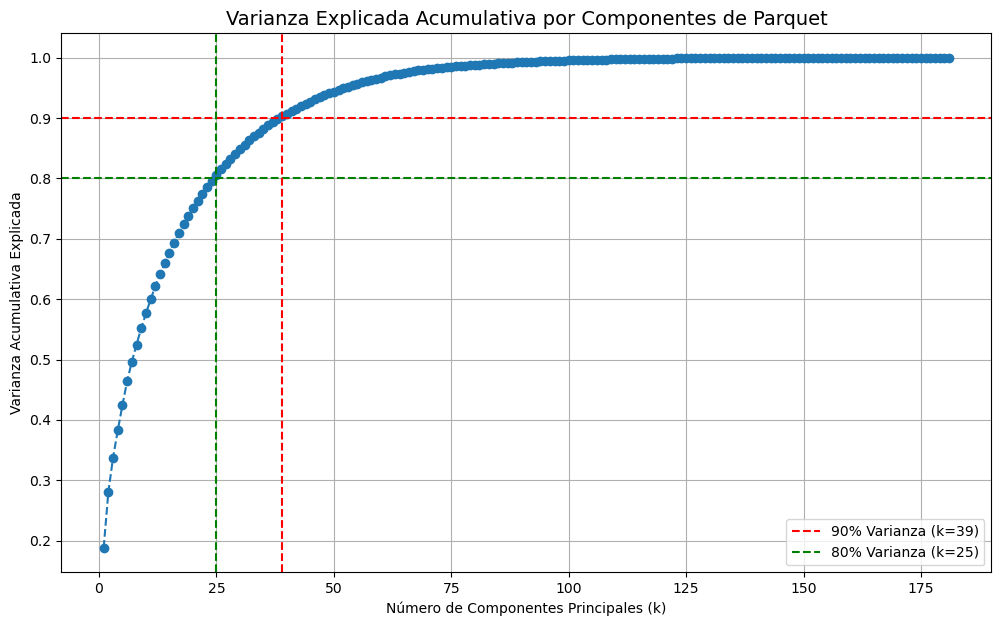


--- Hallazgos del PCA ---
Para capturar el 80% de la varianza, necesitamos k = 25 componentes.
Para capturar el 90% de la varianza, necesitamos k = 39 componentes.

Primeros 20 componentes y su varianza individual:
[0.18820038 0.09270079 0.05665577 0.04502295 0.04216094 0.03970929
 0.03208854 0.02824792 0.0273981  0.02410758 0.02336812 0.02203458
 0.01920331 0.01854488 0.01770815 0.0166822  0.01570455 0.01435927
 0.01367594 0.01307948]


In [14]:
# --- 9.1 Hallazgo de 'k' para PCA (Análisis de Varianza) ---

print(f"Total de features de Parquet a analizar: {len(parquet_feature_cols)}")

# 1. Aislar las features de Parquet de nuestro set de entrenamiento imputado
#    (Usamos 'train_imputed_df')
X_parquet_features = train_imputed_df[parquet_feature_cols]

# 2. Escalar los datos (PCA es sensible a la escala)
scaler_pca = StandardScaler()
X_parquet_scaled = scaler_pca.fit_transform(X_parquet_features)

# 3. Ajustar PCA con todos los componentes para analizar la varianza
#    (n_components=None)
pca_analysis = PCA(n_components=None, random_state=42)
pca_analysis.fit(X_parquet_scaled)

# 4. Calcular la varianza acumulativa
cumulative_variance = np.cumsum(pca_analysis.explained_variance_ratio_)

# --- 9.2 Gráfico de Codo ---
plt.figure(figsize=(12, 7))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulativa por Componentes de Parquet', fontsize=14)
plt.xlabel('Número de Componentes Principales (k)')
plt.ylabel('Varianza Acumulativa Explicada')
plt.grid(True)

# Añadir marcadores para el 80% y 90% de varianza
k_80 = np.argmax(cumulative_variance >= 0.80) + 1
k_90 = np.argmax(cumulative_variance >= 0.90) + 1
plt.axhline(y=0.90, color='r', linestyle='--', label=f'90% Varianza (k={k_90})')
plt.axhline(y=0.80, color='g', linestyle='--', label=f'80% Varianza (k={k_80})')
plt.axvline(x=k_90, color='r', linestyle='--')
plt.axvline(x=k_80, color='g', linestyle='--')
plt.legend()
plt.show()

print("\n--- Hallazgos del PCA ---")
print(f"Para capturar el 80% de la varianza, necesitamos k = {k_80} componentes.")
print(f"Para capturar el 90% de la varianza, necesitamos k = {k_90} componentes.")
print("\nPrimeros 20 componentes y su varianza individual:")
print(pca_analysis.explained_variance_ratio_[:20])

### 9.2 Conclusiones del Análisis PCA y Decisión de 'k'

1.  **El "Codo" (Elbow):** El gráfico muestra un "codo" muy claro alrededor de los 25 componentes. Después de este punto, la curva de varianza acumulativa se aplana, lo que significa que cada componente adicional añade muy poca información nueva.
2.  **Hallazgo Cuantitativo:** Nuestros cálculos confirman esto. Para capturar el **80%** de toda la variabilidad de las 181 *features* de actigrafía, solo necesitamos **k = 25** componentes. Para llegar al 90%, necesitaríamos muchos mas componentes.

**Decisión Metodológica:**
Para nuestra V1, **`k=25`** es la elección óptima. Nos permite:
* Reducir drásticamente la dimensionalidad (de 181 a 25 *features*).
* Capturar el 80% de la señal, eliminando el 20% restante (que es probablemente ruido).
* Prevenir el *overfitting* al entregarle al modelo un conjunto de *features* más pequeño y denso.

**Importante:** No aplicaremos el PCA *ahora*. El `pca_analysis` fue solo para *encontrar* el valor de `k`. El `PCA(n_components=25)` real se ajustará (`.fit()`) *dentro* de nuestro bucle de validación cruzada (solo en los datos de entrenamiento de cada *fold*) para prevenir cualquier fuga de datos.

## 10. Ingeniería de Características Tabular (Dominio)

Ahora que tenemos un *dataset* limpio e imputado, se crearan nuevas variables basadas en el conocimiento del dominio.

En este paso generaremos un total de **17 nuevas features**:

1.  **Contexto de Edad (1 feature):**
    * **`Age_Group`:** Segmentación en grupos (ej. 9-12, 13-15) para contextualizar las métricas fisiológicas.

2.  **Normalización por Edad (13 features):**
    * Un `BMI` de 20 no significa lo mismo a los 8 años que a los 18.
    * Crearemos versiones normalizadas (`_norm`) para 13 métricas clave (incluyendo BMI, Peso, BMR, Grasa Corporal, y pruebas de *fitness* como `FGC_CU` y `FGC_PU`), dividiendo el valor del sujeto por la media de su grupo de edad.
    * Nuevas variables:
      * Métricas Físicas Básicas: `Physical-BMI_norm`, `Physical-Height_norm`, `Physical-Weight_norm`.
      * Composición Corporal (BIA): `BIA-BIA_BMC_norm`, `BIA-BIA_BMI_norm`, `BIA-BIA_BMR_norm`, `BIA-BIA_DEE_norm`, `BIA-BIA_FFM_norm`, `BIA-BIA_Fat_norm`, `BIA-BIA_SMM_norm`, `BIA-BIA_TBW_norm`.
      * FitnessGram (Aptitud Física): `FGC-FGC_CU_norm`, `FGC-FGC_PU_norm`.

3.  **Indicadores de Salud Avanzados (3 features):**
    * **`DEE_BMR`:** Diferencia entre gasto energético total y basal (indicador de nivel de actividad).
    * **`ECW_ICW_Ratio`:** Proporción de agua extracelular/intracelular (indicador de salud celular/hidratación).
    * **`GS_max_norm`:** Fuerza de agarre máxima normalizada por edad.

Al finalizar, estas nuevas variables se unirán a nuestro conjunto de datos para la selección final.

In [15]:
# --- 10. Ingeniería de Características Tabular Completa ---

print("--- Iniciando FE Tabular Avanzada ---")

# 1. Definición de Mapas de Referencia (Basados en análisis clínico/datos)
# Estos valores se usan para normalizar si no queremos usar la media del train set, 
# o como fallback. Aquí usaremos medias del train set para ser consistentes, 
# pero definimos los grupos para la lógica.
age_bins = [0, 8, 12, 15, 18, 22]
age_labels = ['0-8', '9-12', '13-15', '16-18', '19-22']

# 2. Creación de Grupos de Edad
train_imputed_df['Age_Group'] = pd.cut(train_imputed_df['Basic_Demos-Age'], bins=age_bins, labels=age_labels, right=True)
test_imputed_df['Age_Group'] = pd.cut(test_imputed_df['Basic_Demos-Age'], bins=age_bins, labels=age_labels, right=True)

# Convertir a códigos numéricos
train_imputed_df['Age_Group'] = train_imputed_df['Age_Group'].astype('category').cat.codes
test_imputed_df['Age_Group'] = test_imputed_df['Age_Group'].astype('category').cat.codes

# Asegurar que Age_Group esté en la lista de categóricas
if 'Age_Group' not in categorical_cols_for_model:
    categorical_cols_for_model.append('Age_Group')

# 3. Normalización por Grupo de Edad (Métricas Físicas y BIA)
features_to_norm = [
    'Physical-BMI', 'Physical-Height', 'Physical-Weight',
    'BIA-BIA_BMC', 'BIA-BIA_BMI', 'BIA-BIA_BMR', 'BIA-BIA_DEE',
    'BIA-BIA_FFM', 'BIA-BIA_Fat', 'BIA-BIA_SMM', 'BIA-BIA_TBW',
    'FGC-FGC_CU', 'FGC-FGC_PU'
]

# Calcular medias por grupo solo en train
age_group_means = train_imputed_df.groupby('Age_Group')[features_to_norm].mean()

print("Medias por grupo calculadas. Aplicando normalización...")

for col in features_to_norm:
    # Mapear la media
    mean_map_train = train_imputed_df['Age_Group'].map(age_group_means[col])
    mean_map_test = test_imputed_df['Age_Group'].map(age_group_means[col])
    
    # Crear feature normalizada
    train_imputed_df[f'{col}_norm'] = (train_imputed_df[col] / mean_map_train).fillna(1.0)
    test_imputed_df[f'{col}_norm'] = (test_imputed_df[col] / mean_map_test).fillna(1.0)

# 4. Creación de Features Avanzadas (Ratios y Diferencias)

# DEE_BMR (Gasto por Actividad)
train_imputed_df["DEE_BMR"] = train_imputed_df["BIA-BIA_DEE"] - train_imputed_df["BIA-BIA_BMR"]
test_imputed_df["DEE_BMR"] = test_imputed_df["BIA-BIA_DEE"] - test_imputed_df["BIA-BIA_BMR"]

# ECW_ICW_Ratio (Salud Celular)
train_imputed_df["ECW_ICW_Ratio"] = train_imputed_df["BIA-BIA_ECW"] / train_imputed_df["BIA-BIA_ICW"]
test_imputed_df["ECW_ICW_Ratio"] = test_imputed_df["BIA-BIA_ECW"] / test_imputed_df["BIA-BIA_ICW"]

# GS_max_norm (Fuerza de Agarre Normalizada)
# Usaremos la media calculada para consistencia
gs_cols = ['FGC-FGC_GSND', 'FGC-FGC_GSD']
# Calculamos el max de agarre del sujeto
train_imputed_df['GS_max'] = train_imputed_df[gs_cols].max(axis=1)
test_imputed_df['GS_max'] = test_imputed_df[gs_cols].max(axis=1)

# Calculamos la media de ese max por grupo de edad
gs_mean_by_age = train_imputed_df.groupby('Age_Group')['GS_max'].mean()

train_imputed_df['GS_max_norm'] = train_imputed_df['GS_max'] / train_imputed_df['Age_Group'].map(gs_mean_by_age)
test_imputed_df['GS_max_norm'] = test_imputed_df['GS_max'] / test_imputed_df['Age_Group'].map(gs_mean_by_age)


print("\n--- FE Completada ---")
print(f"Total de columnas en train_imputed_df: {train_imputed_df.shape[1]}")

--- Iniciando FE Tabular Avanzada ---
Medias por grupo calculadas. Aplicando normalización...

--- FE Completada ---
Total de columnas en train_imputed_df: 250


## 11. Consolidación de Datasets y Definición de Grupos para Modelado

Con la ingeniería de características avanzada completada, ahora ensamblaremos nuestra lista final de variables predictoras.

**Estrategia de Ensamblaje:**
Construiremos nuestra lista `FEATURES_FINAL` de forma aditiva y controlada:
1.  Tomaremos nuestra lista `FEATURES` existente (que ya contiene las variables tabulares limpias de proxies y las variables de actigrafía).
2.  Le sumaremos explícitamente las **17 nuevas variables** de dominio que acabamos de crear.

Posteriormente, alinearemos los datos eliminando las filas de entrenamiento sin target y definiremos los grupos para el PCA.

In [16]:
# --- 11. Organización y Creación de Datasets Finales ---

# 1. Definir explícitamente las nuevas features creadas en la sección anterior
NEW_FEATURES = [
    'Age_Group',
    'Physical-BMI_norm', 'Physical-Height_norm', 'Physical-Weight_norm',
    'BIA-BIA_BMC_norm', 'BIA-BIA_BMI_norm', 'BIA-BIA_BMR_norm', 'BIA-BIA_DEE_norm',
    'BIA-BIA_FFM_norm', 'BIA-BIA_Fat_norm', 'BIA-BIA_SMM_norm', 'BIA-BIA_TBW_norm',
    'FGC-FGC_CU_norm', 'FGC-FGC_PU_norm',
    'DEE_BMR', 'ECW_ICW_Ratio', 'GS_max_norm'
]

# 2. Construir la lista FEATURES_FINAL
# Sumamos las features seguras que ya teníamos + las nuevas
FEATURES_FINAL = FEATURES + NEW_FEATURES

# 3. Definir grupos de features
PARQUET_FEATURES = parquet_feature_cols

# Las tabulares son el resto (Originales + Nuevas FE)
TABULAR_FEATURES = [col for col in FEATURES_FINAL if col not in PARQUET_FEATURES]

# 4. Actualizar lista de categóricas para el modelo
categorical_cols_final = [col for col in categorical_cols_for_model if col in FEATURES_FINAL]

print(f"Features Originales (Tabular + Parquet): {len(FEATURES)}")
print(f"Nuevas Features de Dominio: {len(NEW_FEATURES)}")
print(f"Total Features Finales: {len(FEATURES_FINAL)}")
print(f" -> Para PCA (Parquet): {len(PARQUET_FEATURES)}")
print(f" -> Directas (Tabulares + Nuevas): {len(TABULAR_FEATURES)}")

# 5. Creación de X e y (Alineación)
X = train_imputed_df[FEATURES_FINAL].copy()
X_test = test_imputed_df[FEATURES_FINAL].copy()

# Recuperamos los targets del dataframe fusionado original
y = train_full[TARGET].copy()
y_sii = train_full[SII_TARGET].copy()

# Filtro de filas válidas (con target) para entrenamiento
valid_target_idx = y.notna() & y_sii.notna()

X = X[valid_target_idx].reset_index(drop=True)
y = y[valid_target_idx].reset_index(drop=True)
y_sii = y_sii[valid_target_idx].reset_index(drop=True)

print("\n--- Datasets Listos para Modelado ---")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X_test shape: {X_test.shape}")

Features Originales (Tabular + Parquet): 232
Nuevas Features de Dominio: 17
Total Features Finales: 249
 -> Para PCA (Parquet): 181
 -> Directas (Tabulares + Nuevas): 68

--- Datasets Listos para Modelado ---
X shape: (2736, 249)
y shape: (2736,)
X_test shape: (20, 249)


## 12. Modelado: Pipeline de Validación Cruzada (CV) Robusta

Nuestro EDA y análisis previo han revelado dos grandes desafíos que este paso debe abordar:
1.  **Datos Ruidosos:** Los datos contenían múltiples nulos (que ya imputamos) y las variables de actigrafía tienen alta dimensionalidad.
2.  **Datos Desbalanceados:** La clase objetivo `3` (Severo) representa solo el 1.2% de los datos, lo que dificulta el aprendizaje.

**Nuestra Estrategia de Modelado:**
En lugar de un entrenamiento simple, implementaremos un **pipeline de validación avanzado** dentro del bucle de entrenamiento.

1.  **CV Robusta:** Usaremos `RepeatedStratifiedKFold` (10 pliegues, 5 repeticiones). Esto promediará los resultados de **50 modelos**, garantizando que nuestro *score* no dependa de un "corte de suerte" de los datos.
2.  **Estratificación:** Usaremos `y_sii` para la estratificación, asegurando que cada *fold* tenga una representación justa de las clases raras.
3.  **PCA (Dentro del Bucle):** Para prevenir rigurosamente la fuga de datos, el ajuste del PCA (`.fit()`) se hará **solo en los datos de entrenamiento de cada fold**. Luego, esa transformación se aplicará a validación y test. Usaremos el `k` óptimo que descubrimos en el paso anterior.
4.  **Aumentación de Datos (Dentro del Bucle):** Para combatir el desbalance, aplicaremos **Sobremuestreo (Oversampling)** de las clases altas y **Ruido Gaussiano** leve a las variables numéricas. Esto solo se aplica al set de entrenamiento, nunca a validación.
5.  **Modelo:** Nuestro caballo de batalla será `LightGBM`, configurado para regresión robusta (`regression_l1`).

**Objetivos:**
* Generar `oof_predictions`: Predicciones fuera de la muestra para todo el set de entrenamiento, vitales para optimizar nuestros umbrales QWK.
* Generar `test_predictions`: El promedio de las 50 predicciones sobre el set de prueba, que constituirá nuestra entrega final.

### Definición de Función de Entrenamiento

Esta función encapsulará todo el bucle de CV, PCA, Aumentación y Entrenamiento

In [17]:
def train_robust_model(model_class, params, X, y, y_stratify, X_test, 
                       parquet_features, categorical_features,
                       k_pca=25, n_splits=10, n_repeats=5, seed=42):
    """
    Pipeline maestro que ejecuta: CV Repetida -> PCA (Train-only) -> Aumentación -> Entrenamiento.
    Maneja diferencias de API entre LightGBM y XGBoost.
    """
    set_seed(seed)
    
    # Configuración de CV
    cv = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    
    # Contenedores
    oof_preds = np.zeros(X.shape[0])
    test_preds = np.zeros(X_test.shape[0])
    models = []
    
    print(f"--- Iniciando entrenamiento: {model_class.__name__} ---")
    print(f"Config: k={k_pca} | CV={n_splits}x{n_repeats}")
    
    # Bucle de Validación
    for fold, (train_idx, val_idx) in enumerate(tqdm(cv.split(X, y_stratify), total=n_splits*n_repeats)):
        
        # 1. División
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # 2. Pipeline PCA (Ajuste solo en Train)
        X_tr_tab = X_tr.drop(columns=parquet_features)
        X_val_tab = X_val.drop(columns=parquet_features)
        X_te_tab = X_test.drop(columns=parquet_features)
        
        X_tr_par = X_tr[parquet_features]
        X_val_par = X_val[parquet_features]
        X_te_par = X_test[parquet_features]
        
        scaler = StandardScaler()
        pca = PCA(n_components=k_pca, random_state=seed)
        
        # Fit-Transform en Train
        X_tr_par_sc = scaler.fit_transform(X_tr_par)
        X_tr_pca = pca.fit_transform(X_tr_par_sc)
        
        # Transform en Val/Test
        X_val_par_sc = scaler.transform(X_val_par)
        X_val_pca = pca.transform(X_val_par_sc)
        
        X_te_par_sc = scaler.transform(X_te_par)
        X_te_pca = pca.transform(X_te_par_sc)
        
        # Reconstrucción de DataFrames
        pca_cols = [f'PCA_{i}' for i in range(k_pca)]
        X_tr_pca = pd.DataFrame(X_tr_pca, columns=pca_cols, index=X_tr.index)
        X_val_pca = pd.DataFrame(X_val_pca, columns=pca_cols, index=X_val.index)
        X_te_pca = pd.DataFrame(X_te_pca, columns=pca_cols, index=X_test.index)
        
        X_tr_final = pd.concat([X_tr_tab, X_tr_pca], axis=1)
        X_val_final = pd.concat([X_val_tab, X_val_pca], axis=1)
        X_te_final = pd.concat([X_te_tab, X_te_pca], axis=1)
        
        # Identificar categóricas presentes
        cat_cols_fold = [c for c in categorical_features if c in X_tr_final.columns]
        
        # 3. Aumentación (Solo en Train)
        X_aug = X_tr_final.copy()
        y_aug = y_tr.copy()
        
        # Sobremuestreo (>49)
        high_score_idx = y_tr[y_tr > 49].index
        X_aug = pd.concat([X_aug, X_tr_final.loc[high_score_idx]])
        y_aug = pd.concat([y_aug, y_tr.loc[high_score_idx]])
        
        # Ruido Gaussiano (solo numéricas)
        num_cols = [c for c in X_aug.columns if c not in cat_cols_fold]
        noise = np.random.normal(0, 0.01, X_aug[num_cols].shape)
        X_aug[num_cols] += noise
        
        # 4. Entrenamiento
        
        # Copiamos params para no afectar otras iteraciones
        current_params = params.copy()
        fit_params = {'eval_set': [(X_val_final, y_val)]}
        
        if "LGBM" in model_class.__name__:
            # LightGBM: early_stopping va en callbacks, verbose en callbacks
            fit_params['categorical_feature'] = cat_cols_fold
            fit_params['eval_metric'] = 'rmse'
            fit_params['callbacks'] = [lgb.early_stopping(100, verbose=False)]
            
        elif "XGB" in model_class.__name__:
            # XGBoost: early_stopping va en constructor, verbose en fit
            current_params['early_stopping_rounds'] = 100
            fit_params['verbose'] = False
        
        # Instanciar y Entrenar
        model = model_class(**current_params)
        model.fit(X_aug, y_aug, **fit_params)
        
        # 5. Predicción
        oof_preds[val_idx] = model.predict(X_val_final)
        test_preds += model.predict(X_te_final) / (n_splits * n_repeats)
        models.append(model)
        
    return oof_preds, test_preds, models

## 13. Optimización de Umbrales y Métrica QWK

Las predicciones (`oof_predictions`) son números continuos (ej. 45.3, 31.2) porque entrenamos un **regresor**.

Debemos convertirilas a clases discretas (`0`, `1`, `2`, `3`) para poder calcular **Kappa Ponderado Cuadrático (QWK).**

**Acción Metodológica:**
Vamos a encontrar los umbrales que mejor traduzcan nuestras predicciones de regresión a clases.

En la siguiente celda, haremos lo siguiente:
1.  Definir una función (`evaluate_predictions`) que tome un conjunto de umbrales (ej. `[30, 50, 80]`) y calcule el *score* QWK.
2.  Usar `scipy.optimize.minimize` para encontrar los 3 umbrales que **maximicen nuestro *score* QWK** en nuestras predicciones `oof_predictions`.
3.  Reportar nuestro *score* final de CV local.

### Definición de función de optimización optimize_thresholds

In [18]:
def optimize_thresholds(y_true, oof_preds):
    """Encuentra los umbrales óptimos para QWK."""
    def evaluate(thresholds, y_t, y_p):
        thresh = np.sort(thresholds)
        preds_class = np.digitize(y_p, thresh)
        return -cohen_kappa_score(y_t, preds_class, weights='quadratic')
    
    res = minimize(evaluate, x0=[30, 50, 80], args=(y_true, oof_preds), method='Nelder-Mead')
    return np.sort(res.x), -res.fun

### Entrenamiento del modelo **LightGBM**

In [19]:
# --- 12. Entrenamiento Modelo 1: LightGBM ---

lgb_params = {
    'objective': 'regression_l1',
    'metric': 'rmse',
    'n_estimators': 2000,
    'learning_rate': 0.01,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'lambda_l1': 1.0,
    'lambda_l2': 1.0,
    'num_leaves': 31,
    'verbose': -1,
    'n_jobs': -1,
    'seed': 42,
    'boosting_type': 'gbdt'
}

# Ejecutar pipeline
lgb_oof, lgb_test, lgb_models = train_robust_model(
    model_class=lgb.LGBMRegressor,
    params=lgb_params,
    X=X, y=y, y_stratify=y_sii, X_test=X_test,
    parquet_features=PARQUET_FEATURES,
    categorical_features=categorical_cols_for_model,
    k_pca=25
)

# Optimizar
lgb_thresh, lgb_score = optimize_thresholds(y_sii, lgb_oof)

print("\nResultados LightGBM:")
print(f"QWK CV Score: {lgb_score:.5f}")
print(f"Umbrales: {lgb_thresh}")

--- Iniciando entrenamiento: LGBMRegressor ---
Config: k=25 | CV=10x5


100%|██████████| 50/50 [04:00<00:00,  4.82s/it]



Resultados LightGBM:
QWK CV Score: 0.37218
Umbrales: [30.48101315 43.00696355 85.47169951]


### Entrenamiento del modelo **XGBoost**

In [20]:
# --- 15. Entrenamiento Modelo 2: XGBoost (Configuración Regularizada) ---

xgb_params = {
    'n_estimators': 2000,
    'learning_rate': 0.01,     # Shrinkage (eta)
    
    # --- Control de Estructura del Árbol ---
    'max_depth': 4,
    'min_child_weight': 5,
    
    # --- Regularización ---
    'gamma': 0.5,
    'reg_lambda': 10,
    'reg_alpha': 0.1,
    
    # --- Submuestreo ---
    'subsample': 0.8,          # Filas
    'colsample_bytree': 0.8,   # Columnas
    
    # --- Otros ---
    'objective': 'reg:absoluteerror',
    'n_jobs': -1,
    'random_state': 42,
    'tree_method': 'hist',
    'enable_categorical': True 
}

# Ejecutar pipeline
xgb_oof, xgb_test, xgb_models = train_robust_model(
    model_class=XGBRegressor,
    params=xgb_params,
    X=X, y=y, y_stratify=y_sii, X_test=X_test,
    parquet_features=PARQUET_FEATURES,
    categorical_features=categorical_cols_for_model,
    k_pca=25
)

# Optimizar
xgb_thresh, xgb_score = optimize_thresholds(y_sii, xgb_oof)

print("\nResultados XGBoost (Regularizado):")
print(f"QWK CV Score: {xgb_score:.5f}")
print(f"Umbrales: {xgb_thresh}")

--- Iniciando entrenamiento: XGBRegressor ---
Config: k=25 | CV=10x5


100%|██████████| 50/50 [02:39<00:00,  3.19s/it]



Resultados XGBoost (Regularizado):
QWK CV Score: 0.37730
Umbrales: [30.7609847  43.37944753 84.1825486 ]
